In [1]:
import json
import pandas as pd

TH_KEYS = [
    "R3,C0", # =_Shift
    "R9,C0", # rshift+space
    "R2,C2", # S_Ctrl
    "R2,C3", # D_Alt
    "R2,C4", # F_WinCmd
    "R7,C1", # J_WinCmd#4
    "R7,C2", # K_Alt#5
    "R7,C3", # L_Ctrl#6
    "R7,C4", # ;_Layer(2)
    "R7,C5", # '_Layer(3)
]

def load_and_preprocess_data(strokes_file, labels_file):
    with open(strokes_file, 'r') as f: strokes = json.load(f)
    with open(labels_file, 'r') as f: labels = json.load(f)

    df = pd.DataFrame(strokes)
    df['intent'] = df['push_ts'].astype(str).map(labels).fillna('Error')
    df = df[df['intent'] != 'Error'].copy()
    df['is_th_key'] = df['id'].isin(TH_KEYS)

    if 'key_name' not in df.columns:
        df['key_name'] = df['id']

    return df

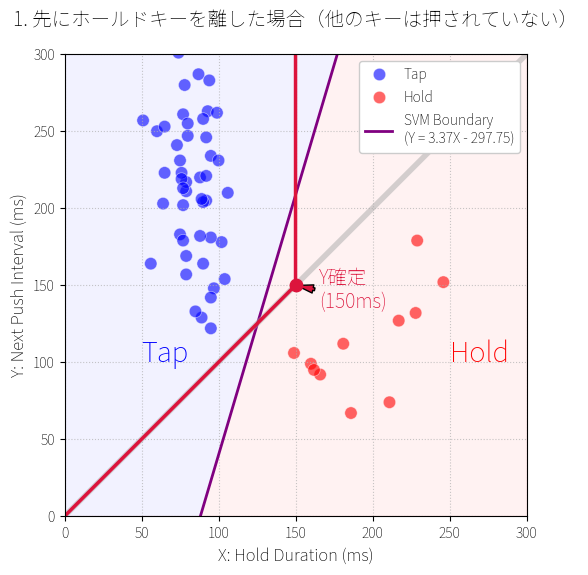

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
import seaborn as sns

# 日本語フォントの設定（環境に合わせて適宜変更してください）
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meiryo', 'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 'Noto Sans CJK JP']
plt.rcParams['font.family'] = 'Noto Sans JP'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'


MAX_TIME = 300
Y_push = 150

def draw_base(df, target_id="R9,C0", ax=None, draw_svm_boundary=True):

    # データ抽出
    df_key = df[df['id'] == target_id].dropna(subset=['next_push_interval']).copy()

    if len(df_key) == 0:
        print(f"エラー: id='{target_id}' の有効なデータが見つかりません。")
        return

    X_features = df_key[['hold_duration', 'next_push_interval']].values
    y_labels = np.where(df_key['intent'] == 'Hold', 1, -1)

    # 線形SVMモデルの学習
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_features, y_labels)
    w1, w2 = clf.coef_[0]
    b = clf.intercept_[0]

    # 1. FigureとAxesオブジェクトの生成 (オブジェクト指向API)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # 2. SVMの決定境界を描画
    # 散布図
    sns.scatterplot(
        data=df_key, x="hold_duration", y="next_push_interval",
        hue="intent", palette={"Tap": "blue", "Hold": "red"},
        alpha=0.6, s=80, edgecolor="w", linewidth=0.5, ax=ax
    )

    if draw_svm_boundary:
        # ====== 境界線の描画 ======
        # Xの描画範囲（0〜500）に合わせてYの値を計算
        x_vals = np.array([0, MAX_TIME])
        if w2 != 0:
            y_vals = (-w1 / w2) * x_vals - (b / w2)
            ax.plot(x_vals, y_vals, color='purple', linestyle='-', linewidth=2,
                    label=f'SVM Boundary\n(Y = {-w1/w2:.2f}X - {b/w2:.2f})')

            # Holdの判定領域を薄く塗りつぶす（視覚的アシスト）
            # w2がマイナスの場合、w1*X + w2*Y + b > 0 は Y < ... となる
            if w2 < 0:
                ax.fill_between(x_vals, 0, y_vals, color='red', alpha=0.05)
                ax.fill_between(x_vals, y_vals, MAX_TIME, color='blue', alpha=0.05)
            else:
                ax.fill_between(x_vals, y_vals, MAX_TIME, color='red', alpha=0.05)
                ax.fill_between(x_vals, 0, y_vals, color='blue', alpha=0.05)
            ax.text(250, 100, 'Hold', color='red', fontsize=20, fontweight='bold')
            ax.text(50,100, 'Tap', color='blue', fontsize=20, fontweight='bold')

    ax.set_xlim(0, MAX_TIME)
    ax.set_ylim(0, MAX_TIME)
    ax.set_xlabel('X: Hold Duration (ms)', fontsize=12)
    ax.set_ylabel('Y: Next Push Interval (ms)', fontsize=12)

    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right', framealpha=1.0)
    ax.set_aspect('equal') # X軸とY軸のスケールを揃える


def draw_path_y_settled(ax):
    # 軸の範囲とラベル設定
    ax.set_title('1. 先にホールドキーを離した場合（他のキーは押されていない）', fontsize=14, pad=20)

    # 1. どちらも未確定の場合の経路 (y=x上を進行)
    ax.plot([0, MAX_TIME], [0, MAX_TIME], color='darkgray', linewidth=4, alpha=0.5,
            label='')

    # 3. Next Push(Y)が先行して確定した場合の経路
    # (0,0) -> (Y, Y) までは未確定、そこから垂直に (∞, Y) へ
    x3_path = [0, Y_push, Y_push]
    y3_path = [0, Y_push, MAX_TIME]
    ax.plot(x3_path, y3_path, color='crimson', linewidth=2.5,
            label='')

    # 確定ポイントのマーカーと注釈
    ax.scatter([Y_push], [Y_push], color='crimson', s=80, zorder=5)
    ax.annotate(f'Y確定\n({Y_push}ms)', xy=(Y_push, Y_push), xytext=(Y_push + 15, Y_push -15),
                arrowprops=dict(facecolor='crimson', shrink=0.05, width=2, headwidth=6),
                color='crimson', fontweight='bold', fontsize=14)



# 関数の実行
if __name__ == "__main__":
    STROKES_FILE = "../preprocessed/strokes_svm_it3.json"
    LABELS_FILE = "../preprocessed/labels_svm_it3.json"
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)

    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, target_id="R9,C0", ax=ax)
    draw_path_y_settled(ax)

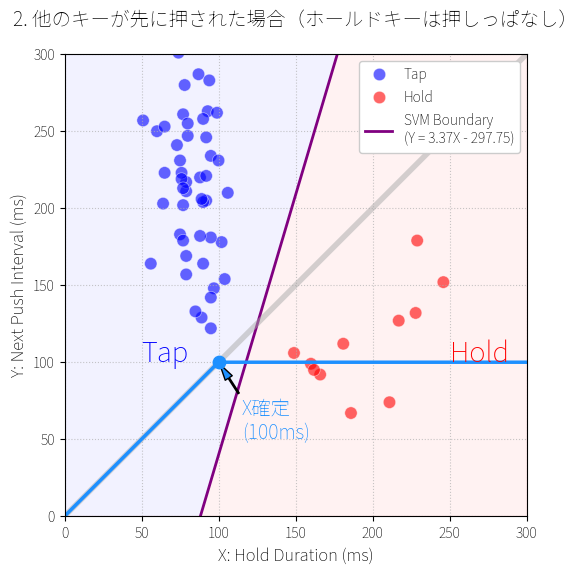

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
import seaborn as sns

# 日本語フォントの設定（環境に合わせて適宜変更してください）
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meiryo', 'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 'Noto Sans CJK JP']
plt.rcParams['font.family'] = 'Noto Sans JP'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

def draw_path_x_settled(ax):
    ax.set_title('2. 他のキーが先に押された場合（ホールドキーは押しっぱなし）', fontsize=14, pad=20)
    # --- 経路の描画 ---
    # サンプル値の設定
    X_release = 100  # パターン2: 100msでHoldキーを離した

    # 1. どちらも未確定の場合の経路 (y=x上を進行)
    ax.plot([0, MAX_TIME], [0, MAX_TIME], color='darkgray', linewidth=4, alpha=0.5, label='')

    # 2. Holdリリース(X)が先行して確定した場合の経路
    # (0,0) -> (X, X) までは未確定、そこから水平に (X, ∞) へ
    x2_path = [0, X_release, MAX_TIME]
    y2_path = [0, X_release, X_release]
    ax.plot(x2_path, y2_path, color='dodgerblue', linewidth=2.5, label='')

    # 確定ポイントのマーカーと注釈
    ax.scatter([X_release], [X_release], color='dodgerblue', s=80, zorder=5)
    ax.annotate(f'X確定\n({X_release}ms)', xy=(X_release, X_release), xytext=(X_release + 15, X_release - 50),
                arrowprops=dict(facecolor='dodgerblue', shrink=0.05, width=1, headwidth=6),
                color='dodgerblue', fontweight='bold', fontsize=14)



# 関数の実行
if __name__ == "__main__":
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)
    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, target_id="R9,C0", ax=ax)
    draw_path_x_settled(ax)

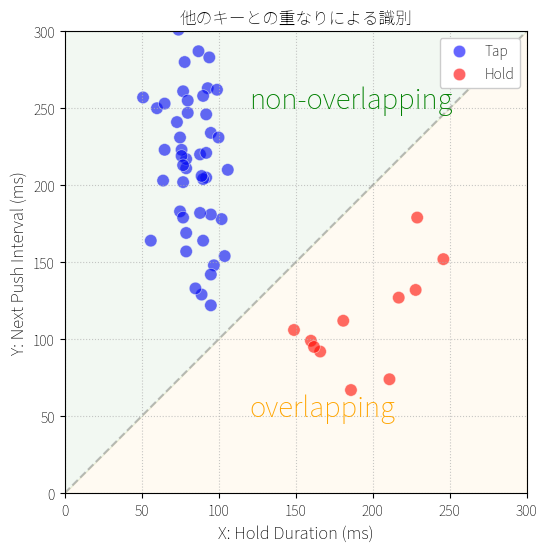

In [4]:
def draw_trivial_tap_region(ax):
    # 基本となる y = x の対角線
    ax.plot([0, MAX_TIME], [0, MAX_TIME], color='gray', linestyle='--', alpha=0.5)

    ax.fill_between(
        [MAX_TIME,0], [MAX_TIME, 0], MAX_TIME,
        color='green', alpha=0.05
    )
    ax.text(120, 250, 'non-overlapping', color='green', fontsize=20, fontweight='bold')
    ax.fill_between(
        [MAX_TIME,0], [MAX_TIME, 0], 0,
        color='orange', alpha=0.05
    )
    ax.text(120, 50, 'overlapping', color='orange', fontsize=20, fontweight='bold')
    ax.legend(loc='upper right', framealpha=1.0)


if __name__ == "__main__":
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)

    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, target_id="R9,C0", ax=ax, draw_svm_boundary=False)
    draw_trivial_tap_region(ax)
    ax.set_title("他のキーとの重なりによる識別")

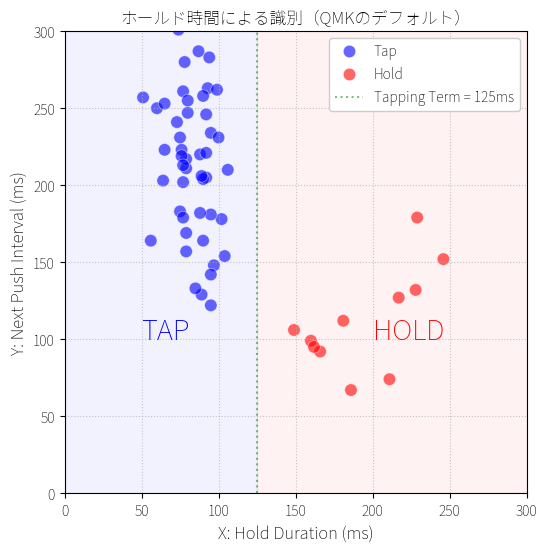

In [5]:
def draw_trivial_tap_region(ax, tapping_term=125):
    # 基本となる y = x の対角線
    ax.plot([tapping_term, tapping_term], [0, MAX_TIME], color='green', linestyle=':', alpha=0.5, label=f'Tapping Term = {tapping_term}ms')

    ax.fill_between(
        [0, tapping_term], [0, 0], MAX_TIME
        ,
        color='blue', alpha=0.05
    )
    ax.text(50, 100, 'TAP', color='blue', fontsize=20, fontweight='bold')
    ax.fill_between(
        [tapping_term, MAX_TIME], [0, 0], MAX_TIME,
        color='red', alpha=0.05
    )
    ax.text(200, 100, 'HOLD', color='red', fontsize=20, fontweight='bold')
    ax.legend(loc='upper right', framealpha=1.0)


if __name__ == "__main__":
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)

    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, target_id="R9,C0", ax=ax, draw_svm_boundary=False)
    draw_trivial_tap_region(ax)
    ax.set_title("ホールド時間による識別（QMKのデフォルト）")

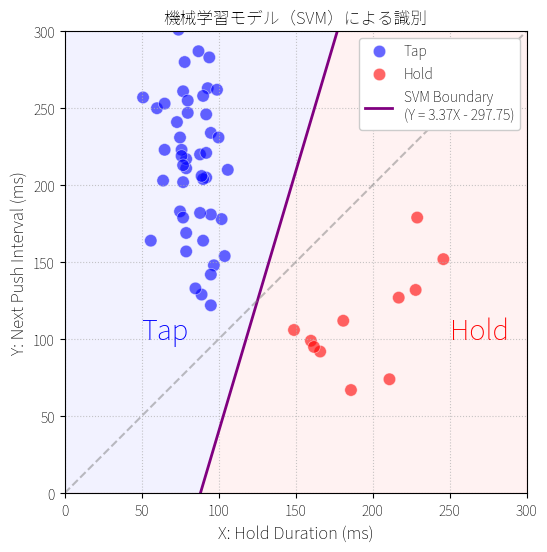

In [6]:
def draw_diagonal_line(ax):
    ax.plot([0, MAX_TIME], [0, MAX_TIME], color='gray', linestyle='--', alpha=0.5)

if __name__ == "__main__":
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)

    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, target_id="R9,C0", ax=ax, draw_svm_boundary=True)
    draw_diagonal_line(ax)
    ax.set_title("機械学習モデル（SVM）による識別")

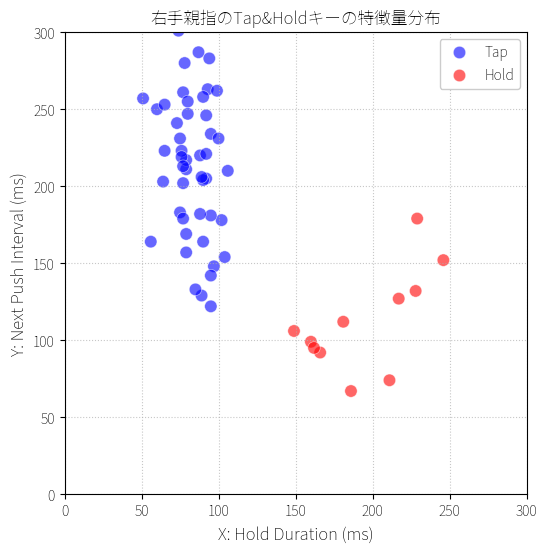

In [8]:
def draw_diagonal_line(ax):
    ax.plot([0, MAX_TIME], [0, MAX_TIME], color='gray', linestyle='--', alpha=0.5)

if __name__ == "__main__":
    df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)

    _, ax = plt.subplots(figsize=(6, 6))
    draw_base(df_merged, ax=ax, draw_svm_boundary=False)
    ax.set_title("右手親指のTap&Holdキーの特徴量分布")